# Leading XGBoost Model and Explainability

Tunes the deployed leading-signal model, evaluates held-out ranking performance, measures lead time, and generates SHAP evidence.

**Execution contract:** run from top to bottom. The notebook writes reproducible artifacts under `data/processed/` and `reports/`; raw data and large generated artifacts remain outside Git.


## 1. Imports and configuration

Pin project-relative paths and load the exact analytical dependencies used by the workflow.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
)
from xgboost import XGBClassifier


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FEATURE_MATRIX = ROOT / "data" / "processed" / "instacart" / "features" / "instacart_feature_matrix.pkl"
LABELS = ROOT / "data" / "processed" / "instacart" / "labels" / "instacart_phase2_decay_labels.csv"
PREDICTIONS_DIR = ROOT / "data" / "processed" / "instacart" / "predictions"
MODEL_DIR = ROOT / "models" / "phase4"
REPORT_DIR = ROOT / "reports" / "modeling" / "instacart"

KEY_COLS = ["user_id", "order_id"]
TARGET_COL = "early_decay_label"
SPLIT_COL = "leading_time_proxy_split"
BASELINE_PREFIX = "base_"


## 2. Reusable analytical helpers

Define validation, transformation, scoring, and reporting helpers without mutating project artifacts.


In [2]:
def ensure_dirs() -> None:
    PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    REPORT_DIR.mkdir(parents=True, exist_ok=True)


def leading_feature_columns(df: pd.DataFrame) -> list[str]:
    non_predictors = {*KEY_COLS, "split", TARGET_COL}
    return [
        col
        for col in df.columns
        if col not in non_predictors and not col.startswith(BASELINE_PREFIX)
    ]


def add_label_metadata(matrix: pd.DataFrame) -> pd.DataFrame:
    label_cols = [
        "user_id",
        "order_id",
        "relative_day",
        "next_gap_days",
        "historical_median_gap_days",
        "known_gap_count_to_date",
        "label_eligible",
        "label_status",
    ]
    labels = pd.read_csv(LABELS, usecols=label_cols)
    merged = matrix.merge(labels, on=KEY_COLS, how="left", validate="one_to_one")
    if merged["relative_day"].isna().any():
        missing = int(merged["relative_day"].isna().sum())
        raise ValueError(f"Missing label metadata for {missing:,} matrix rows")
    return merged


def add_relative_time_proxy_split(df: pd.DataFrame) -> pd.DataFrame:
    """User-level split using Instacart relative timeline.

    Instacart does not provide global calendar dates. This is therefore a defensible
    temporal proxy, not a true calendar-time split.
    """
    user_completion = (
        df.groupby("user_id", as_index=False)["relative_day"]
        .max()
        .rename(columns={"relative_day": "user_observation_completion_day"})
        .sort_values(["user_observation_completion_day", "user_id"], kind="mergesort")
        .reset_index(drop=True)
    )
    n_users = user_completion.shape[0]
    train_cut = int(n_users * 0.70)
    validation_cut = int(n_users * 0.85)
    user_completion[SPLIT_COL] = "test"
    user_completion.loc[: train_cut - 1, SPLIT_COL] = "train"
    user_completion.loc[train_cut : validation_cut - 1, SPLIT_COL] = "validation"
    out = df.merge(user_completion, on="user_id", how="left", validate="many_to_one")
    return out


def top_lift(y_true: pd.Series, scores: np.ndarray, fraction: float) -> dict[str, float | int]:
    ranked = pd.DataFrame({"y_true": y_true.astype(int).to_numpy(), "score": scores})
    ranked = ranked.sort_values("score", ascending=False)
    n = max(1, int(len(ranked) * fraction))
    top_rate = float(ranked.head(n)["y_true"].mean())
    base_rate = float(ranked["y_true"].mean())
    return {
        "fraction": fraction,
        "rows": n,
        "positive_rate": top_rate,
        "lift": float(top_rate / base_rate) if base_rate else float("nan"),
    }


def threshold_at_top_fraction(scores: np.ndarray, fraction: float) -> float:
    return float(np.quantile(scores, 1 - fraction))


def evaluate(y_true: pd.Series, scores: np.ndarray, threshold: float) -> dict[str, object]:
    preds = scores >= threshold
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        preds,
        average="binary",
        zero_division=0,
    )
    return {
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
        "threshold": threshold,
        "precision_at_threshold": float(precision),
        "recall_at_threshold": float(recall),
        "f1_at_threshold": float(f1),
        "classification_report": classification_report(y_true, preds, zero_division=0),
        "top_5_pct": top_lift(y_true, scores, 0.05),
        "top_10_pct": top_lift(y_true, scores, 0.10),
    }


def timing_metric(test_frame: pd.DataFrame, threshold: float) -> dict[str, object]:
    scored = test_frame.copy()
    scored["flagged"] = scored["risk_score"] >= threshold
    positive_events = scored[scored[TARGET_COL]].copy()
    if positive_events.empty:
        return {
            "positive_event_users": 0,
            "correctly_flagged_users": 0,
            "correctly_flagged_user_rate": 0.0,
            "days_before_decay_threshold_summary": {},
            "days_before_next_observed_order_summary": {},
        }

    positive_events["decay_event_day"] = (
        positive_events["relative_day"] + 2.0 * positive_events["historical_median_gap_days"]
    )
    positive_events["next_observed_order_day"] = positive_events["relative_day"] + positive_events["next_gap_days"]
    first_event = (
        positive_events.sort_values(["user_id", "decay_event_day", "order_id"])
        .groupby("user_id", as_index=False)
        .first()
    )

    flagged = scored[scored["flagged"]].copy()
    candidates = flagged.merge(
        first_event[
            [
                "user_id",
                "decay_event_day",
                "next_observed_order_day",
                "order_id",
            ]
        ].rename(columns={"order_id": "event_order_id"}),
        on="user_id",
        how="inner",
        validate="many_to_one",
    )
    candidates = candidates[candidates["relative_day"] <= candidates["decay_event_day"]].copy()
    if candidates.empty:
        return {
            "positive_event_users": int(first_event["user_id"].nunique()),
            "correctly_flagged_users": 0,
            "correctly_flagged_user_rate": 0.0,
            "days_before_decay_threshold_summary": {},
            "days_before_next_observed_order_summary": {},
        }

    first_flag = (
        candidates.sort_values(["user_id", "relative_day", "order_id"])
        .groupby("user_id", as_index=False)
        .first()
    )
    first_flag["days_before_decay_threshold"] = first_flag["decay_event_day"] - first_flag["relative_day"]
    first_flag["days_before_next_observed_order"] = first_flag["next_observed_order_day"] - first_flag["relative_day"]

    def summarize(series: pd.Series) -> dict[str, float]:
        return {
            "mean": float(series.mean()),
            "median": float(series.median()),
            "p25": float(series.quantile(0.25)),
            "p75": float(series.quantile(0.75)),
            "min": float(series.min()),
            "max": float(series.max()),
        }

    return {
        "positive_event_users": int(first_event["user_id"].nunique()),
        "correctly_flagged_users": int(first_flag["user_id"].nunique()),
        "correctly_flagged_user_rate": float(first_flag["user_id"].nunique() / first_event["user_id"].nunique()),
        "threshold_definition": "validation top 10 percent risk-score cutoff",
        "event_definition": "relative_day + 2 * historical_median_gap_days for the first positive test snapshot per user",
        "days_before_decay_threshold_summary": summarize(first_flag["days_before_decay_threshold"]),
        "days_before_next_observed_order_summary": summarize(first_flag["days_before_next_observed_order"]),
    }


def fit_model(X_train: pd.DataFrame, y_train: pd.Series, params: dict[str, object]) -> XGBClassifier:
    params = params.copy()
    params.pop("weight_multiplier", None)
    auto_scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    scale_pos_weight = float(params.pop("scale_pos_weight", auto_scale_pos_weight))
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        **params,
    )
    model.fit(X_train, y_train)
    return model


def tune_model(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_validation: pd.DataFrame,
    y_validation: pd.Series,
) -> tuple[XGBClassifier, dict[str, object], list[dict[str, object]]]:
    auto_scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    base_params = {
        "n_estimators": 180,
        "max_depth": 5,
        "learning_rate": 0.08,
        "subsample": 0.85,
        "colsample_bytree": 0.90,
    }
    candidates = [
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.08, "subsample": 0.85, "colsample_bytree": 0.85},
        {"n_estimators": 250, "max_depth": 3, "learning_rate": 0.06, "subsample": 0.90, "colsample_bytree": 0.85},
        {"n_estimators": 180, "max_depth": 5, "learning_rate": 0.08, "subsample": 0.85, "colsample_bytree": 0.90},
        {"n_estimators": 250, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.90, "colsample_bytree": 0.90},
        {
            **base_params,
            "scale_pos_weight": auto_scale_pos_weight * 0.35,
            "weight_multiplier": 0.35,
        },
        {
            **base_params,
            "scale_pos_weight": auto_scale_pos_weight * 0.65,
            "weight_multiplier": 0.65,
        },
        {
            **base_params,
            "scale_pos_weight": auto_scale_pos_weight * 0.80,
            "weight_multiplier": 0.80,
        },
        {
            "n_estimators": 300,
            "max_depth": 4,
            "learning_rate": 0.05,
            "subsample": 0.90,
            "colsample_bytree": 0.90,
            "scale_pos_weight": auto_scale_pos_weight * 0.65,
            "weight_multiplier": 0.65,
        },
        {
            "n_estimators": 220,
            "max_depth": 6,
            "learning_rate": 0.06,
            "subsample": 0.85,
            "colsample_bytree": 0.90,
            "scale_pos_weight": auto_scale_pos_weight * 0.65,
            "weight_multiplier": 0.65,
            "min_child_weight": 3,
            "reg_lambda": 2.0,
        },
    ]
    results: list[dict[str, object]] = []
    best_model: XGBClassifier | None = None
    best_result: dict[str, object] | None = None
    for params in candidates:
        model = fit_model(X_train, y_train, params)
        scores = model.predict_proba(X_validation)[:, 1]
        threshold = threshold_at_top_fraction(scores, 0.10)
        metrics = evaluate(y_validation, scores, threshold)
        result = {
            "params": params,
            "validation_roc_auc": metrics["roc_auc"],
            "validation_pr_auc": metrics["pr_auc"],
            "validation_top_5_lift": metrics["top_5_pct"]["lift"],
            "validation_top_10_lift": metrics["top_10_pct"]["lift"],
        }
        results.append(result)
        if best_result is None or (
            result["validation_pr_auc"],
            result["validation_top_5_lift"],
        ) > (
            best_result["validation_pr_auc"],
            best_result["validation_top_5_lift"],
        ):
            best_model = model
            best_result = result
    if best_model is None or best_result is None:
        raise RuntimeError("No XGBoost model was trained")
    return best_model, best_result, results


def save_shap_values(model: XGBClassifier, X_test: pd.DataFrame, test_keys: pd.DataFrame, output_path: Path) -> None:
    dtest = xgb.DMatrix(X_test, feature_names=X_test.columns.tolist())
    contributions = model.get_booster().predict(dtest, pred_contribs=True)
    shap_feature_cols = [f"shap_{col}" for col in X_test.columns]
    shap_df = pd.DataFrame(contributions[:, :-1], columns=shap_feature_cols, index=X_test.index)
    shap_df.insert(0, "order_id", test_keys["order_id"].to_numpy())
    shap_df.insert(0, "user_id", test_keys["user_id"].to_numpy())
    shap_df["shap_bias"] = contributions[:, -1]
    shap_df.to_pickle(output_path)


def write_report(report: dict[str, object]) -> None:
    with (REPORT_DIR / "phase4_leading_xgboost_report.json").open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, default=str)

    test_metrics = report["test_metrics"]
    timing = report["timing_metric"]
    lines = [
        "# Phase 4 Leading XGBoost Report",
        "",
        "## Scope",
        "",
        "Focused Phase 4 deliverable for the behavioral leading-indicator model. This uses only leading feature columns from the master feature matrix and trains XGBoost with class imbalance handling.",
        "",
        "## Important Split Caveat",
        "",
        "Instacart does not provide global calendar dates. The requested real time-based split is not directly possible. The implemented split is a user-level relative-time proxy: users are sorted by their latest eligible `relative_day`, then split into earlier train, middle validation, and later test groups. This preserves user separation and avoids random row splitting.",
        "",
        "## Input",
        "",
        f"- Master feature matrix rows: {report['matrix_rows']:,}",
        f"- Leading feature columns: {report['leading_feature_count']:,}",
        "",
        "## Split Summary",
        "",
        "| Split | Rows | Users | Positives | Positive Rate |",
        "|---|---:|---:|---:|---:|",
    ]
    for row in report["split_summary"]:
        split_name = row.get("split", row.get(SPLIT_COL))
        lines.append(
            f"| {split_name} | {int(row['rows']):,} | {int(row['users']):,} | "
            f"{int(row['positives']):,} | {float(row['positive_rate']):.2%} |"
        )
    lines.extend(
        [
            "",
            "## Test Metrics",
            "",
            f"- ROC-AUC: {test_metrics['roc_auc']:.4f}",
            f"- PR-AUC: {test_metrics['pr_auc']:.4f}",
            f"- Top 5% lift: {test_metrics['top_5_pct']['lift']:.2f}x",
            f"- Top 10% lift: {test_metrics['top_10_pct']['lift']:.2f}x",
            f"- Precision at validation top-10% threshold: {test_metrics['precision_at_threshold']:.2%}",
            f"- Recall at validation top-10% threshold: {test_metrics['recall_at_threshold']:.2%}",
            "",
            "## Timing Metric",
            "",
            f"- Positive-event users in test: {timing['positive_event_users']:,}",
            f"- Correctly flagged positive-event users: {timing['correctly_flagged_users']:,}",
            f"- Correctly flagged user rate: {timing['correctly_flagged_user_rate']:.2%}",
        ]
    )
    if timing["days_before_decay_threshold_summary"]:
        lead = timing["days_before_decay_threshold_summary"]
        observed = timing["days_before_next_observed_order_summary"]
        lines.extend(
            [
                f"- Median days before label-defined decay threshold: {lead['median']:.2f}",
                f"- Mean days before label-defined decay threshold: {lead['mean']:.2f}",
                f"- Median days before next observed order: {observed['median']:.2f}",
                f"- Mean days before next observed order: {observed['mean']:.2f}",
            ]
        )
    lines.extend(
        [
            "",
            "## Best Hyperparameters",
            "",
            "```json",
            json.dumps(report["best_validation_result"]["params"], indent=2),
            "```",
            "",
            "## Outputs",
            "",
        ]
    )
    for name, path in report["outputs"].items():
        lines.append(f"- {name}: `{path}`")
    (REPORT_DIR / "phase4_leading_xgboost_report.md").write_text("\n".join(lines) + "\n", encoding="utf-8")


## 3. Pipeline definition

Define the end-to-end workflow. Execution is deliberately isolated in the next cell so the expensive step is explicit.


In [3]:
def main() -> None:
    ensure_dirs()
    matrix = pd.read_pickle(FEATURE_MATRIX)
    matrix[TARGET_COL] = matrix[TARGET_COL].astype(bool)
    feature_cols = leading_feature_columns(matrix)
    if not feature_cols:
        raise ValueError("No leading feature columns found")

    modeling = add_label_metadata(matrix)
    modeling = add_relative_time_proxy_split(modeling)

    train = modeling[modeling[SPLIT_COL] == "train"].copy()
    validation = modeling[modeling[SPLIT_COL] == "validation"].copy()
    test = modeling[modeling[SPLIT_COL] == "test"].copy()

    user_overlap = {
        "train_validation": int(len(set(train["user_id"]) & set(validation["user_id"]))),
        "train_test": int(len(set(train["user_id"]) & set(test["user_id"]))),
        "validation_test": int(len(set(validation["user_id"]) & set(test["user_id"]))),
    }
    if any(user_overlap.values()):
        raise ValueError(f"User overlap across splits found: {user_overlap}")

    X_train, y_train = train[feature_cols], train[TARGET_COL]
    X_validation, y_validation = validation[feature_cols], validation[TARGET_COL]
    X_test, y_test = test[feature_cols], test[TARGET_COL]

    model, best_result, tuning_results = tune_model(X_train, y_train, X_validation, y_validation)
    validation_scores = model.predict_proba(X_validation)[:, 1]
    threshold = threshold_at_top_fraction(validation_scores, 0.10)
    test_scores = model.predict_proba(X_test)[:, 1]

    validation_metrics = evaluate(y_validation, validation_scores, threshold)
    test_metrics = evaluate(y_test, test_scores, threshold)

    test_predictions = test[[*KEY_COLS, SPLIT_COL, TARGET_COL, "relative_day", "next_gap_days", "historical_median_gap_days"]].copy()
    test_predictions["risk_score"] = test_scores
    test_predictions["flagged_at_threshold"] = test_predictions["risk_score"] >= threshold
    predictions_path = PREDICTIONS_DIR / "leading_xgboost_time_proxy_test_predictions.csv"
    test_predictions.to_csv(predictions_path, index=False)

    model_path = MODEL_DIR / "leading_xgboost_time_proxy.pkl"
    joblib.dump(
        {
            "model": model,
            "feature_columns": feature_cols,
            "threshold": threshold,
            "split_method": "user_level_relative_time_proxy",
            "best_validation_result": best_result,
        },
        model_path,
    )

    shap_path = PREDICTIONS_DIR / "leading_xgboost_time_proxy_test_shap_values.pkl"
    save_shap_values(model, X_test, test[[*KEY_COLS]], shap_path)

    split_summary = (
        modeling.groupby(SPLIT_COL)
        .agg(
            rows=(TARGET_COL, "count"),
            users=("user_id", "nunique"),
            positives=(TARGET_COL, "sum"),
            positive_rate=(TARGET_COL, "mean"),
            min_completion_day=("user_observation_completion_day", "min"),
            max_completion_day=("user_observation_completion_day", "max"),
        )
        .reset_index()
    )

    report = {
        "matrix_rows": int(matrix.shape[0]),
        "leading_feature_count": int(len(feature_cols)),
        "leading_feature_columns": feature_cols,
        "split_method": "user_level_relative_time_proxy",
        "split_caveat": "Instacart has no global calendar dates; relative_day is user-lifecycle time, not real calendar time.",
        "user_overlap": user_overlap,
        "split_summary": split_summary.to_dict(orient="records"),
        "class_weighting": {
            "auto_scale_pos_weight_train": float((y_train == 0).sum() / max((y_train == 1).sum(), 1)),
            "selected_scale_pos_weight": float(
                best_result["params"].get(
                    "scale_pos_weight",
                    (y_train == 0).sum() / max((y_train == 1).sum(), 1),
                )
            ),
            "selected_weight_multiplier": best_result["params"].get("weight_multiplier", 1.0),
        },
        "tuning_results": tuning_results,
        "best_validation_result": best_result,
        "validation_metrics": validation_metrics,
        "test_metrics": test_metrics,
        "timing_metric": timing_metric(test_predictions, threshold),
        "outputs": {
            "trained_model": model_path.relative_to(ROOT).as_posix(),
            "test_predictions": predictions_path.relative_to(ROOT).as_posix(),
            "test_shap_values": shap_path.relative_to(ROOT).as_posix(),
            "report_md": (REPORT_DIR / "phase4_leading_xgboost_report.md").relative_to(ROOT).as_posix(),
            "report_json": (REPORT_DIR / "phase4_leading_xgboost_report.json").relative_to(ROOT).as_posix(),
        },
    }
    write_report(report)

    print(
        json.dumps(
            {
                "leading_feature_count": len(feature_cols),
                "split_summary": split_summary.to_dict(orient="records"),
                "validation_pr_auc": validation_metrics["pr_auc"],
                "test_pr_auc": test_metrics["pr_auc"],
                "test_roc_auc": test_metrics["roc_auc"],
                "timing_metric": report["timing_metric"],
                "outputs": report["outputs"],
            },
            indent=2,
            default=str,
        )
    )


## 4. Execute the workflow

Run the complete stage and retain its console output in the committed notebook.


In [4]:
main()


{
  "leading_feature_count": 38,
  "split_summary": [
    {
      "leading_time_proxy_split": "test",
      "rows": 1075413,
      "users": 25718,
      "positives": 156767,
      "positive_rate": 0.14577376319609303,
      "min_completion_day": 309.0,
      "max_completion_day": 365.0
    },
    {
      "leading_time_proxy_split": "train",
      "rows": 833721,
      "users": 120014,
      "positives": 178652,
      "positive_rate": 0.21428271568066534,
      "min_completion_day": 2.0,
      "max_completion_day": 234.0
    },
    {
      "leading_time_proxy_split": "validation",
      "rows": 580201,
      "users": 25717,
      "positives": 109505,
      "positive_rate": 0.18873631724178344,
      "min_completion_day": 234.0,
      "max_completion_day": 309.0
    }
  ],
  "validation_pr_auc": 0.34783126880479753,
  "test_pr_auc": 0.25852226020555197,
  "test_roc_auc": 0.660650352675686,
  "timing_metric": {
    "positive_event_users": 23892,
    "correctly_flagged_users": 5203,
    "c

## 5. Results and generated evidence

Render the generated report directly in the notebook so GitHub visitors can inspect results without running the project.


# Phase 4 Leading XGBoost Report

## Scope

Focused Phase 4 deliverable for the behavioral leading-indicator model. This uses only leading feature columns from the master feature matrix and trains XGBoost with class imbalance handling.

## Important Split Caveat

Instacart does not provide global calendar dates. The requested real time-based split is not directly possible. The implemented split is a user-level relative-time proxy: users are sorted by their latest eligible `relative_day`, then split into earlier train, middle validation, and later test groups. This preserves user separation and avoids random row splitting.

## Input

- Master feature matrix rows: 2,489,335
- Leading feature columns: 38

## Split Summary

| Split | Rows | Users | Positives | Positive Rate |
|---|---:|---:|---:|---:|
| test | 1,075,413 | 25,718 | 156,767 | 14.58% |
| train | 833,721 | 120,014 | 178,652 | 21.43% |
| validation | 580,201 | 25,717 | 109,505 | 18.87% |

## Test Metrics

- ROC-AUC: 0.6607
- PR-AUC: 0.2585
- Top 5% lift: 2.46x
- Top 10% lift: 2.13x
- Precision at validation top-10% threshold: 35.53%
- Recall at validation top-10% threshold: 12.68%

## Timing Metric

- Positive-event users in test: 23,892
- Correctly flagged positive-event users: 5,203
- Correctly flagged user rate: 21.78%
- Median days before label-defined decay threshold: 12.00
- Mean days before label-defined decay threshold: 24.65
- Median days before next observed order: 18.00
- Mean days before next observed order: 29.47

## Best Hyperparameters

```json
{
  "n_estimators": 220,
  "max_depth": 6,
  "learning_rate": 0.06,
  "subsample": 0.85,
  "colsample_bytree": 0.9,
  "scale_pos_weight": 2.3833757808476816,
  "weight_multiplier": 0.65,
  "min_child_weight": 3,
  "reg_lambda": 2.0
}
```

## Outputs

- trained_model: `models/phase4/leading_xgboost_time_proxy.pkl`
- test_predictions: `data/processed/instacart/predictions/leading_xgboost_time_proxy_test_predictions.csv`
- test_shap_values: `data/processed/instacart/predictions/leading_xgboost_time_proxy_test_shap_values.pkl`
- report_md: `reports/modeling/instacart/phase4_leading_xgboost_report.md`
- report_json: `reports/modeling/instacart/phase4_leading_xgboost_report.json`


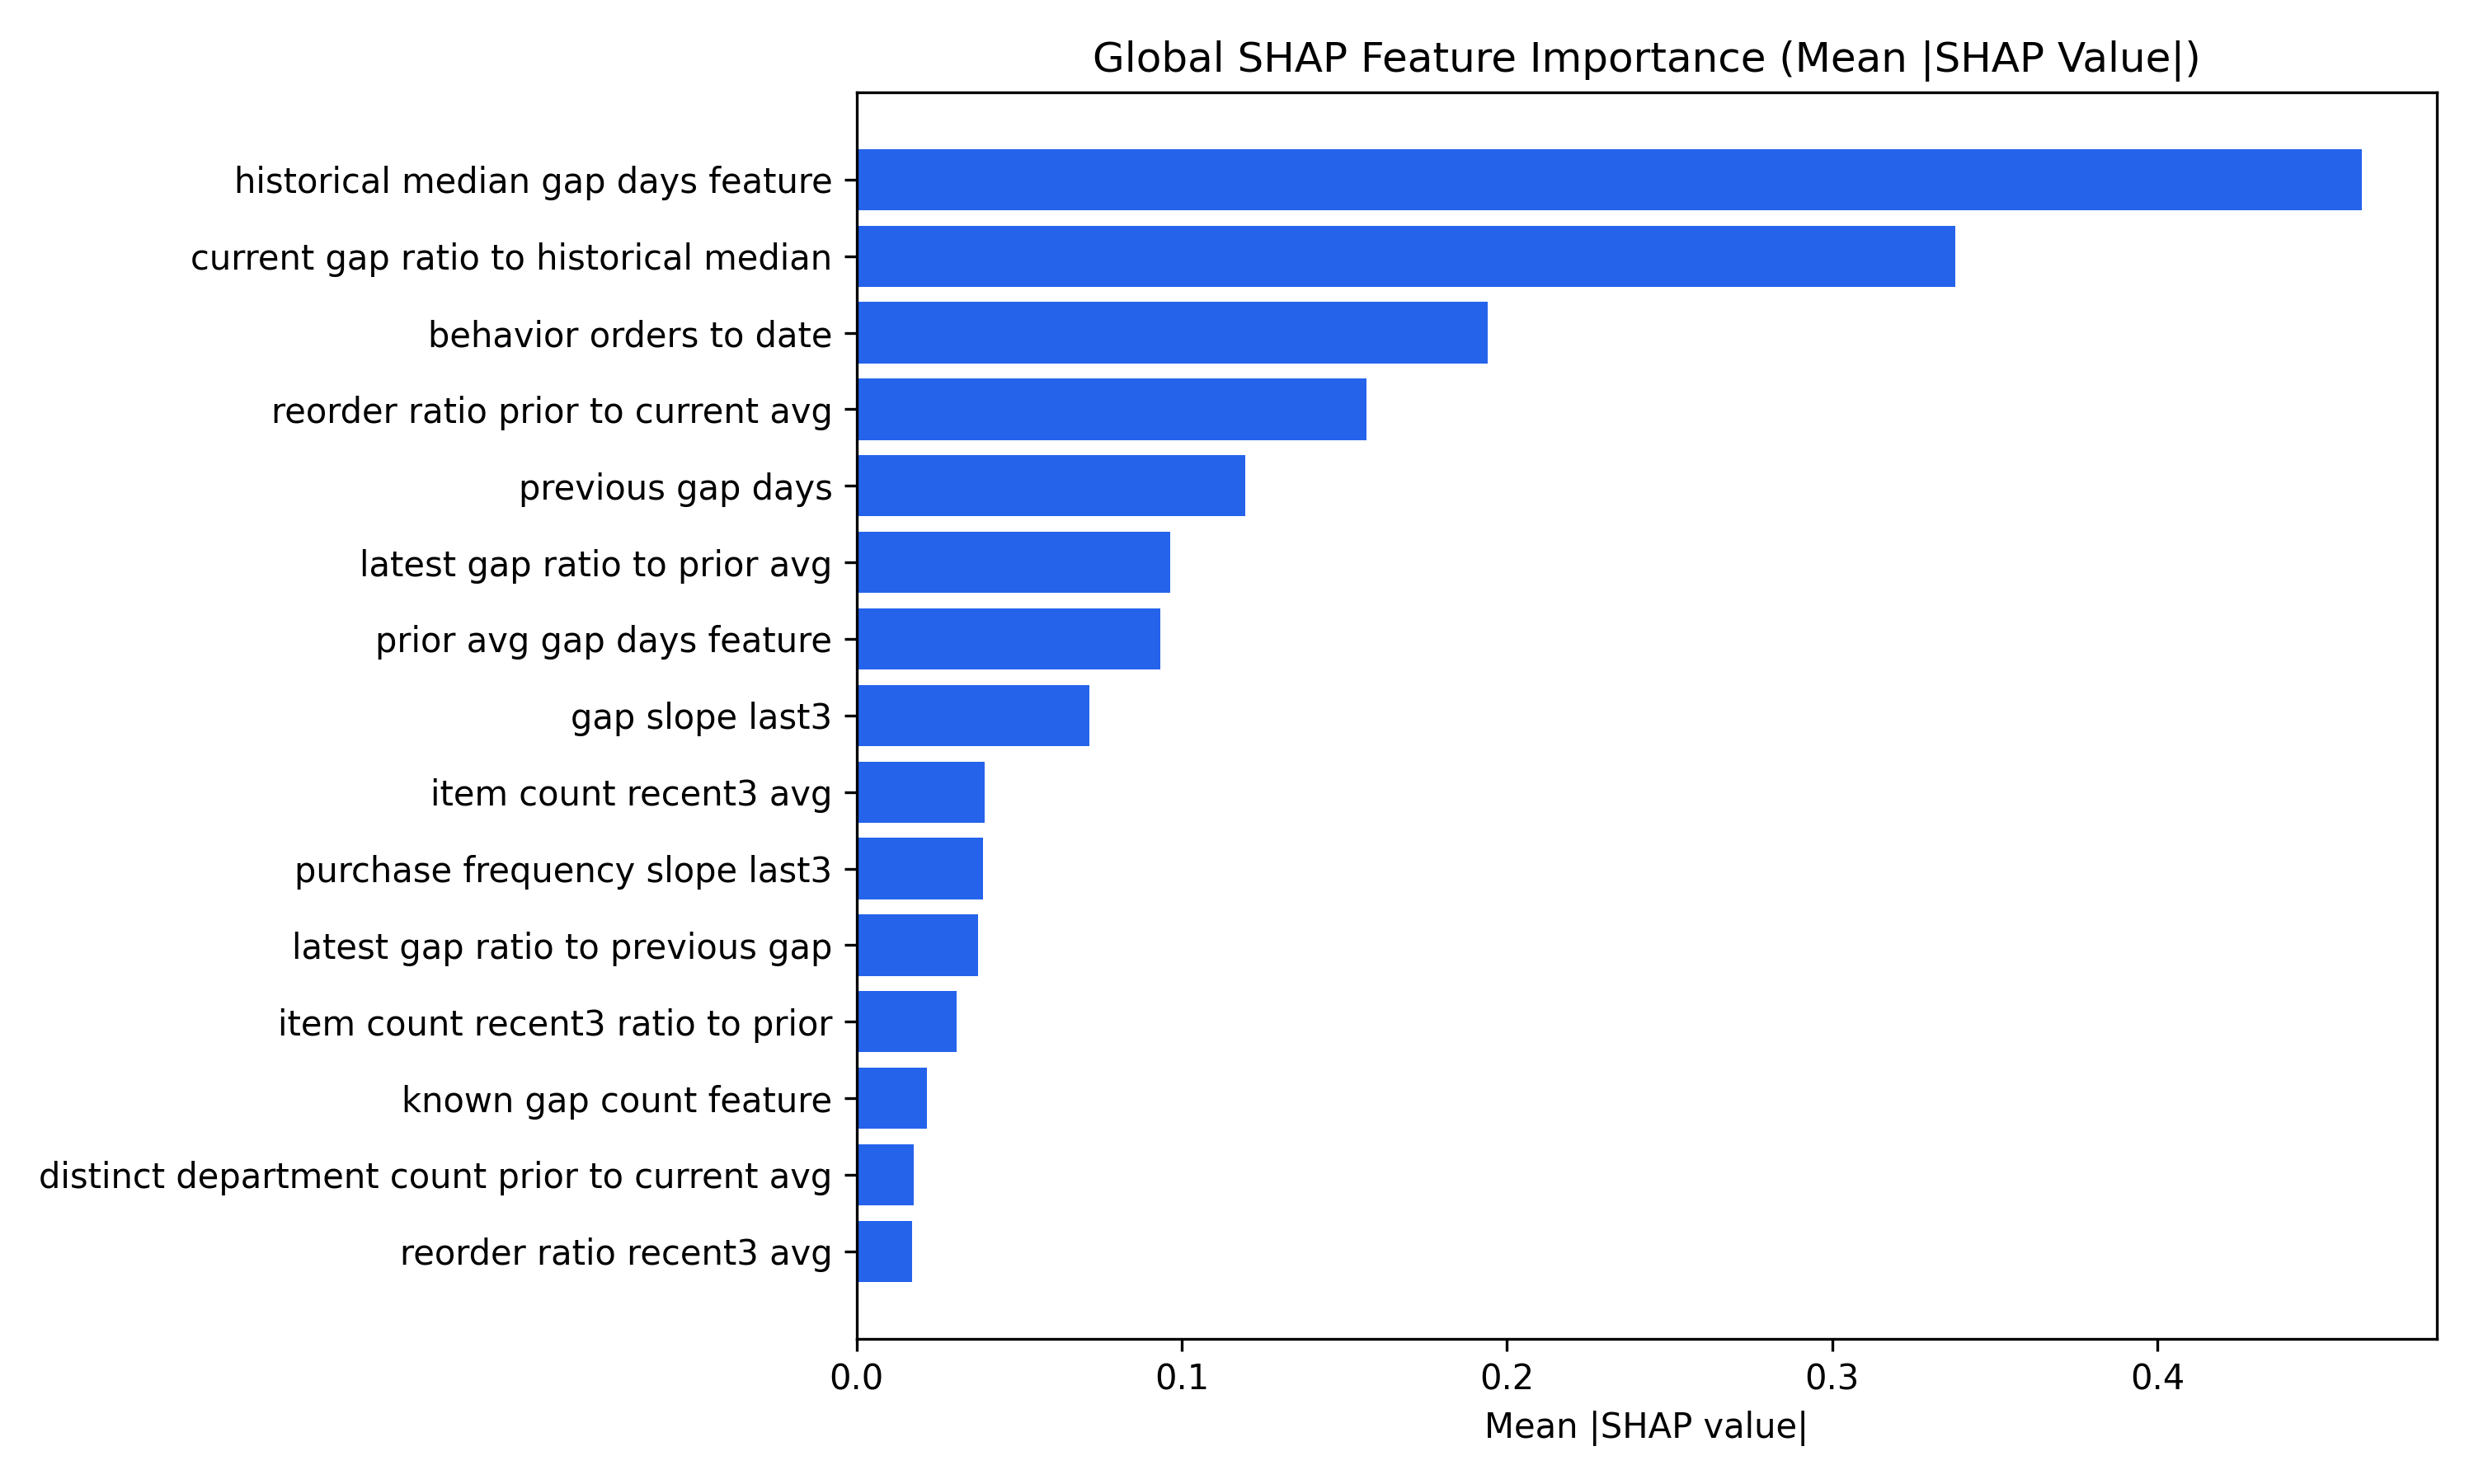

In [5]:
from IPython.display import Image, Markdown, display
report_path = ROOT.joinpath(*["reports","modeling","instacart","phase4_leading_xgboost_report.md"])
display(Markdown(report_path.read_text(encoding="utf-8")))
evidence_plot = ROOT.joinpath(*["reports","modeling","instacart","plots","shap_global_importance.png"])
display(Image(filename=str(evidence_plot)))
